# Titanic Machine Learning Project



### 1. Setup and Data Loading


**1.1 Import libraries**

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Reproductibility
np.random.seed(42)


**1.2 Import the titanic data**

In [88]:
DATA_PATH = Path("datasets/titanic")
train_df = pd.read_csv(DATA_PATH / "train.csv")
test_df = pd.read_csv(DATA_PATH / "test.csv")

In [89]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [90]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Both dataset loaded successfully. Let's find out data set's structure  before deep dive deep Exploratory Data Analysis

**1.3 Short Observations**

In [91]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


As we seen above, Cabin has a lot of null values and also Age does have NULL values this is our first observation.

In [92]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


Same with the above almost same proportion of `Age and Cabin` is missing in the test dataset.

In [93]:
train_df["Survived"].value_counts(normalize = True)
# normalize = True does convert raw counts into relative frequencies (proportions that sum to 1.0)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [94]:
print(f"Shape of Train dataset {train_df.shape}")
print(f"Shape of Test dataset {test_df.shape}")

Shape of Train dataset (891, 12)
Shape of Test dataset (418, 11)


In [95]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


`PassengerID` - Drop it. It's an arbitrary index, no signal or correlation with the dataset.


`Name` : The full name has no signal. But the **title embedded in the name does**. 'Mr' , 'Miss', 'Master', 'Dr' ,'Rev' etc. Think about what a title encodes. It's a proxy for sex, age, band, marital status, and social rank. 'Master' specifically means a young boy, which is real signal given 'women and children first' Extracting **Title** from **Name** with a custom transformer is one of the highest=value engineered features on this dataset. So don't use Name raw, but don't drop it before extracting Title.


`Ticket`: It's messy, shared ticket numbers indicate groups travelling together. It's a lower value-per-effort. Reasonable to investigate briefly in EDA and drop if it looks too nosiy.

`Cabin`: Here's the nuance 77% missing means we can't imput it sensibly. But before dropping consider: Is the missingness itself informative ? A common trick is to engineer a binary HasCabin feature (1 if cabin recored, 0 if note). The hyphotehesis: cabin was more likely recorded for higher-class passengers, so missingess correlated with class adn possibly survivalc. You could also extract just the deck letter (C85 -> C)


## Step 2: Exploratory Data Analysis



#### 2.1 Categorical Features versus Survival.

For `Sex`, `Pclass`, `Embarked`, group by each and look at the mean of Survived (since it's 0/1 , the mean is the survival rate) You're checking: does this feature separate survivors from non-survivors ?

In [96]:
train_df["Survived"].mean()

0.3838383838383838

In [97]:
train_df.groupby(by = 'Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

`Sex` female 74% survival versus male 19%. That's a massive gap. This is the single strongest predictor in the whole dataset. 'Women and children first' shows up directly in the numbers. Definetly keep it.

In [98]:
train_df.groupby(by = 'Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

`Pclass` 1st class 63%, 2nd 47%, 3rd 24%. Clear monotonic gradient. Higher class, higher survival. Strong feature, keep. Note it's ordinal (1<2<3 means something), which is a small decision for later. one-hot encode it, or treat as ordinal ? Either works; one-hot is the safe default.

In [99]:
train_df.groupby(by = 'Embarked')["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

`Embarked` C 55%, Q 39%, S 34%. There's a real spread, so it has some signal. But be a little skeptical. Embarked is probaly correlated with Pclass (Cherbourg likely had more 1st-class passengers) so partt o this 'signal' may just be Pclass leaking through. Keep it, but it's a weaker feature than the first two.

### 2.2 Numerical features versus Survival

for `Age` and `Fare` those are continous variables and we can't just groupby a continous variable. There are two options bin them (e.g. `pd.cut` Age into child/teen/adult/senior) then compare survival per bin. or plot overlapping histograms one for survivors one forf non-survivors and see if the distribution is differ.



In [100]:
train_df.groupby(by = pd.cut(train_df["Age"], bins = [0,12,18,35,60,100], labels= ["Child", "Teen","Adult","Senior","Elder"]), observed=True)["Survived"].mean() 

Age
Child     0.579710
Teen      0.428571
Adult     0.382682
Senior    0.400000
Elder     0.227273
Name: Survived, dtype: float64

Age does carry signal, but it's concentrated at the extremes, being a child helps a lot, being elderly hurts. The middle three bands are clustered around 38% which is uninformative.<br>
This tells something useful for Step3: the relationship between Age and survival is non-linear (high at low age, drops off, low at high age) A linear model like `LogisticRegression` will struggle to capture 'extremes matter, middle doesn't' from raw Age it can only fit a straight line through it. Two implictions:

- Tree-based models (RandomForest, GradientBoosting) will handle raw Age fine. They split on thresholds naturally.
- If you want a linear model to use Age well, feedin it the banded version (or an IsChild binary flag) often works bettern than raw Age. This is the same lesson as Cabin earlier. the engineered form can beat the raw form. 

In [101]:
train_df.groupby(by = pd.qcut(train_df["Fare"], q = 4, labels=["Low-end", 'Medium', 'High', 'First Class']), observed=True)["Survived"].mean()

Fare
Low-end        0.197309
Medium         0.303571
High           0.454955
First Class    0.581081
Name: Survived, dtype: float64

A clear, monotonic climb. Higher fare, higher survival. no surprises or kinks.

So Fare has strong signal but here's the thing to notice this curve almost identical to the Pclass curve we found earlier. That's not a coincidence. Fare and Pclass are basically measuring the same underlying thing. 

This is **multicollinearity**. and it's worth flagging now for step 3:


`Cabin` Let's look at the cabin feature transform it to are people have Cabin or Not (we're knowing from the dataset if it's null there is no cabin if it's a value then it has a cabin)

In [102]:
def has_cabin(value):
    if pd.isna(value):
        return "No"
    return "Yes"
train_df["HasCabin"] = train_df["Cabin"].apply(has_cabin)
train_df["HasCabin"]

0       No
1      Yes
2       No
3      Yes
4       No
      ... 
886     No
887    Yes
888     No
889    Yes
890     No
Name: HasCabin, Length: 891, dtype: object

In [103]:
train_df.groupby("HasCabin")["Survived"].mean()

HasCabin
No     0.299854
Yes    0.666667
Name: Survived, dtype: float64

No cabin recorded 30% of survival chance while Cabin recorded 67% survival.

In [104]:
train_df["Parch"]

0      0
1      0
2      0
3      0
4      0
      ..
886    0
887    0
888    2
889    0
890    0
Name: Parch, Length: 891, dtype: int64

`FamilySize` let's create a familySize feature depends on `SibSp` = number of siblings + Spouses  and `Parch` = number of Parents + Childrent abroad. 

In [105]:
train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1
train_df["FamilySize"]

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: FamilySize, Length: 891, dtype: int64

In [106]:
train_df.groupby(by = "FamilySize")["Survived"].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [107]:
train_df["FamilySize"].value_counts()

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

## Exploratory Data Analysis Done.

### Feature Decision  Iteration 1

PRE-PIPELINE (create these columns first, on train AND test)
- HasCabin    = Cabin.notna()
- FamilySize  = SibSp + Parch + 1

NUMERICAL pipeline: SimpleImputer(median) → StandardScaler
- Age, Fare, FamilySize

CATEGORICAL pipeline: SimpleImputer(most_frequent) → OneHotEncoder
- Sex, Pclass, Embarked, HasCabin

DROP: PassengerId, Cabin, Ticket, SibSp, Parch, Name

ITERATION 2 (later): Title feature, Title-aware Age imputation, raw-vs-banded tuning

In [108]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,No,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Yes,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,No,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Yes,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,No,1


## Step 3 PipeLines

#### Preparation for the Pipelines.

In [109]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["HasCabin"] = df["Cabin"].notna()

    return df
DATA_PATH = Path("datasets/titanic")
train_df = pd.read_csv(DATA_PATH / "train.csv")
test_df = pd.read_csv(DATA_PATH / "test.csv") 

train_df = add_features(train_df)
test_df = add_features(test_df)



Separate X(features) and y(Survived) label in train dataset.

In [110]:
y = train_df["Survived"]
X = train_df.drop(columns = ["Survived"], axis = 1)

#### Split data into stratified train_test_split

In [111]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)


In [112]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,True
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,False


In [113]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


num_cols = ["Age", "Fare", "FamilySize"]
cat_cols = ["HasCabin", "Embarked", "Pclass", "Sex"]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown= "ignore")),
])


preprocess = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols),
])

X_train_processed = preprocess.fit_transform(X_train)
X_train_processed.shape

(712, 13)

In [114]:
preprocess.get_feature_names_out()

array(['num__Age', 'num__Fare', 'num__FamilySize', 'cat__HasCabin_False',
       'cat__HasCabin_True', 'cat__Embarked_C', 'cat__Embarked_Q',
       'cat__Embarked_S', 'cat__Pclass_1', 'cat__Pclass_2',
       'cat__Pclass_3', 'cat__Sex_female', 'cat__Sex_male'], dtype=object)

## Step 4 : Baseline Models

Now attach a classifier and measure. The goal train several models, compare them fairly with cross-validation, pick a winner to tune in Step 5.

In [115]:
from sklearn.model_selection import cross_val_score


from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("logisticregression", LogisticRegression(max_iter=1000))
])
lr_score = cross_val_score(lr_pipeline, X_train, y_train, cv = 5, scoring = 'accuracy')
print(f"LogisticRegression MEAN SCORE (CROSS-VALIDATION K-FOLD = 5): {lr_score.mean():.4f}" )
print(f"LogisticRegression STD SCORE (CROSS-VALIDATION K-FOLD = 5): {lr_score.std():.4f}")

LogisticRegression MEAN SCORE (CROSS-VALIDATION K-FOLD = 5): 0.8006
LogisticRegression STD SCORE (CROSS-VALIDATION K-FOLD = 5): 0.0239


In [116]:
from sklearn.ensemble import RandomForestClassifier


rf_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("RandomForestClassifier", RandomForestClassifier(random_state=42))
])

rf_score = cross_val_score(rf_pipeline, X_train, y_train, cv = 5, scoring="accuracy")
print(f"RandomForestClassifier MEAN SCORE (CROSS-VALIDATION K-FOLD = 5): {rf_score.mean():.4f}")
print(f"RandomForestClassifier STD SCORE (CROSS-VALIDATION K-FOLD = 5): {rf_score.std():.4f}")

RandomForestClassifier MEAN SCORE (CROSS-VALIDATION K-FOLD = 5): 0.7810
RandomForestClassifier STD SCORE (CROSS-VALIDATION K-FOLD = 5): 0.0495


In [117]:
from sklearn.svm import SVC

svc_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("SVC", SVC(random_state=42))
])

svc_score = cross_val_score(svc_pipeline, X_train, y_train, cv = 5, scoring = 'accuracy')
print(f"SVC MEAN SCORE (CROSS-VALIDATION K-FOLD = 5): {svc_score.mean():.4f}")
print(f"SVC STD SCORE (CROSS-VALIDATION K-FOLD = 5): {svc_score.std():.4f}")

SVC MEAN SCORE (CROSS-VALIDATION K-FOLD = 5): 0.8245
SVC STD SCORE (CROSS-VALIDATION K-FOLD = 5): 0.0216


SVC - Highest mean and lowest std. It's both the best performer and the most consistent across folds. That's the ideal combination. It's genuinely the leader, not a lucky fold.

Random Forest - not just lowest mean, but double the std of the others. High variance across folds is the signature of overfitting. The model behaves quite differently depending on which slice of data it trains on, because deep unrestricted trees memorize fold-specific noise. This confirms what I suspected: default RandomForest is overfitting on 712 rows.

Logistic Regression - solid, stable, middle of the pack. A linear model on a mostly-linear problem; little drama.

## Step 5: Fine-tuning the Models



In [118]:
param_dist = {
    "RandomForestClassifier__n_estimators": [100, 200, 300, 400, 500],
    "RandomForestClassifier__max_depth": [None, 4, 6, 8, 10],
    "RandomForestClassifier__min_samples_leaf": [1, 2, 4, 8],
}

from sklearn.model_selection import RandomizedSearchCV

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv = 5,
    scoring = 'accuracy',
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)
print(f"Best Score: {rf_search.best_score_}")
print(f"Best Parameters: {rf_search.best_params_}")
import numpy as np
results = rf_search.cv_results_
best_idx = rf_search.best_index_
print(f"Best config std: {results['std_test_score'][best_idx]:.4f}")

Best Score: 0.8175022160937655
Best Parameters: {'RandomForestClassifier__n_estimators': 300, 'RandomForestClassifier__min_samples_leaf': 4, 'RandomForestClassifier__max_depth': None}
Best config std: 0.0295


In [119]:
svc_param_dist = {
    "SVC__C": [0.1, 1, 10, 100],
    "SVC__gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1],
    "SVC__kernel": ["rbf"],
}

svc_search = RandomizedSearchCV(
    svc_pipeline,
    param_distributions=svc_param_dist,
    n_iter=20,
    cv = 5,
    scoring = 'accuracy',
    random_state=42,
    n_jobs=-1
)

svc_search.fit(X_train, y_train)
print(f"Best Score : {svc_search.best_score_}")
print(svc_search.best_params_)
best_idx = svc_search.best_index_
print(f"std: {svc_search.cv_results_['std_test_score'][best_idx]:.4f}")


Best Score : 0.8286910272825766
{'SVC__kernel': 'rbf', 'SVC__gamma': 0.01, 'SVC__C': 100}
std: 0.0153


## Step 6: Final Evaluation & Error Analysis

#### Step 6a - get predictions from both models.

In [120]:
rf_best = rf_search.best_estimator_
svc_best = svc_search.best_estimator_

rf_val_preds = rf_best.predict(X_val)
svc_val_preds = svc_best.predict(X_val)

#### Step 6b - accuracy, and the comparison that matters.

In [121]:
from sklearn.metrics import accuracy_score
print(f"RF val accuracy:  {accuracy_score(y_val, rf_val_preds):.4f}")
print(f"SVC val accuracy: {accuracy_score(y_val, svc_val_preds):.4f}")

RF val accuracy:  0.8045
SVC val accuracy: 0.8212


#### Time for the metrics, confusion matrix + classification report for both models.

In [122]:
from sklearn.metrics import confusion_matrix, classification_report

In [123]:
print(confusion_matrix(y_val, rf_val_preds))
print(classification_report(y_val, rf_val_preds))

[[102   8]
 [ 27  42]]
              precision    recall  f1-score   support

           0       0.79      0.93      0.85       110
           1       0.84      0.61      0.71        69

    accuracy                           0.80       179
   macro avg       0.82      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179



In [124]:
print(confusion_matrix(y_val, svc_val_preds))
print(classification_report(y_val, svc_val_preds))

[[101   9]
 [ 23  46]]
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       110
           1       0.84      0.67      0.74        69

    accuracy                           0.82       179
   macro avg       0.83      0.79      0.80       179
weighted avg       0.82      0.82      0.82       179



## Step 6 — Model Comparison: RF vs SVC on Validation Set

Both tuned models evaluated on the held-out validation set (`X_val`, 179 passengers, never seen during training or cross-validation).

### Headline Numbers

| Metric | Random Forest | SVC | Winner |
|---|---|---|---|
| Validation accuracy | 0.8045 | 0.8212 | SVC |
| CV accuracy (5-fold) | 0.8175 | 0.8287 | SVC |
| CV to Val gap | -0.013 | -0.008 | — |

Both validation scores landed just below their CV scores — a small, healthy drop that confirms the cross-validation was honest and there is no data leakage.

### Confusion Matrices

Layout: `[[TN, FP], [FN, TP]]` — class 0 = died, class 1 = survived.

**Random Forest:** TN=102, FP=8, FN=27, TP=42

**SVC:** TN=101, FP=9, FN=23, TP=46

### Per-Class Performance

| Class | Metric | RF | SVC |
|---|---|---|---|
| 0 — Died | Precision | 0.79 | 0.81 |
| 0 — Died | Recall | 0.93 | 0.92 |
| 0 — Died | F1 | 0.85 | 0.86 |
| 1 — Survived | Precision | 0.84 | 0.84 |
| 1 — Survived | Recall | 0.61 | 0.67 |
| 1 — Survived | F1 | 0.71 | 0.74 |

### Key Findings

- **SVC outperforms RF on every aggregate metric** — accuracy, macro F1, and survivor-class F1. The ordering is consistent across baseline, tuned, and held-out evaluation, so SVC is genuinely the stronger model on this data.
- **Both models share the same bias: they predict "died" more reliably than "survived."** Recall on the survived class is only 0.61 (RF) and 0.67 (SVC), meaning RF misses 27 of 69 real survivors and SVC misses 23. This is driven by class imbalance — about 62% of passengers died, so the model leans toward the majority class.
- **Accuracy alone hides this.** RF's 0.80 accuracy looks fine, but it quietly misclassifies 39% of survivors. The per-class recall is what exposes the weakness.
- **Both models are cautious about predicting survival:** high survivor precision (0.84) but lower recall — when the model says "survived" it is usually right, but it lets many survivors slip through as false negatives.
- The validation set is small (179 rows), so the roughly 1.7-point accuracy gap is about 3 passengers. SVC is the correct pick on the evidence, but both models sit in the same low-80s range.

### Decision

**SVC selected as the final model** — best validation accuracy (0.8212), best survivor-class F1 (0.74), and the lowest cross-validation variance of all models tested.

### Open Question (Iteration 2)

Survivor recall of 0.67 may be too low if missing a survivor is the costly error. This can be addressed by shifting the decision threshold via SVC's `decision_function` to trade precision for recall — to be explored next session.

### Precision/Recall Trade-off.



In [125]:
y_val_scores = svc_best.decision_function(X_val)
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_scores)

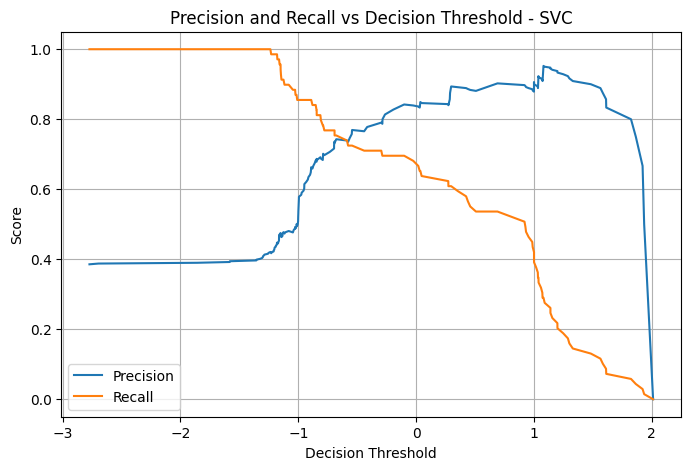

In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8,5))
plt.plot(thresholds, precisions[:-1], label = "Precision")
plt.plot(thresholds, recalls[:-1], label = "Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Decision Threshold - SVC")
plt.legend()
plt.grid(True)
plt.show()


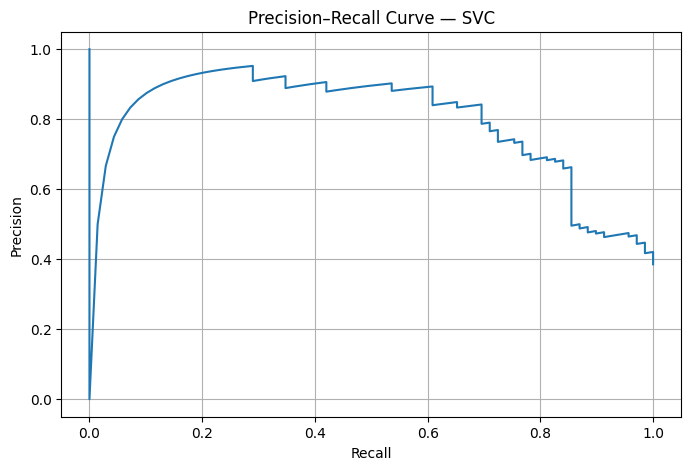

In [127]:
plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — SVC")
plt.grid(True)
plt.show()

## Conclusion

### What This Notebook Covered

An end-to-end binary classification project on the Titanic dataset, built as a hands-on refresher of scikit-learn fundamentals (Chapters 1-3).

Workflow: EDA → feature engineering → preprocessing pipeline → baseline models → hyperparameter tuning → evaluation and error analysis.

### Key Steps

- **EDA** — Identified the strongest predictors: `Sex` (74% vs 19% survival), the wealth cluster (`Pclass`, `Fare`, `HasCabin`), and non-linear effects in `Age` and `FamilySize`.
- **Feature engineering** — Created `HasCabin` (from missingness, 30% vs 67% survival) and `FamilySize` (from `SibSp + Parch + 1`, showing a clear U-shaped survival pattern).
- **Preprocessing** — A `ColumnTransformer` combining a numerical pipeline (median imputation + scaling) and a categorical pipeline (most-frequent imputation + one-hot encoding), producing 13 features.
- **Models** — Compared Logistic Regression, Random Forest, and SVC with 5-fold cross-validation.
- **Tuning** — `RandomizedSearchCV` on RF and SVC. Tuning lifted RF from 0.7810 to 0.8175 and cut its variance nearly in half (0.0495 → 0.0295).

### Final Result

**SVC** selected as the final model — validation accuracy **0.8212**, survivor-class F1 **0.74**, lowest cross-validation variance of all models tested. Validation scores landed just below CV scores for both models, confirming honest cross-validation and no data leakage.

### Key Takeaways

- Accuracy alone is misleading on imbalanced data — per-class recall revealed both models are biased toward predicting "died" and miss roughly a third of real survivors.
- The precision/recall trade-off is a tunable choice: shifting the decision threshold trades one against the other, with a clear cost cliff past ~0.85 recall.
- Hyperparameter tuning closes the gap between a model's default and best configuration — large payoff for RF (poor defaults, overfitting), minor for SVC (defaults already near-optimal).
- A feature being unusable in raw form does not make it worthless — `Cabin` and `Name` carry signal once engineered.

### Possible Iteration 2 Improvements

- Extract `Title` from `Name` as a feature.
- Title-aware median Age imputation via a custom transformer.
- Test raw vs. banded versions of `Age`, `Fare`, and `FamilySize`.
- Apply a custom decision threshold if survivor recall is prioritized.